In [33]:
import torch
words = ['h','e','l','l','o','w','o','r','l','d']
chars = ['h','e','l','o','w','r','d']
data_size, vocab_size = len(words), len(chars)
ctoi = { ch:i for i,ch in enumerate(chars) }
itoc = { ch:i for i,ch in ctoi.items() }
print(len(itoc))


7


In [34]:
ctoi

{'h': 0, 'e': 1, 'l': 2, 'o': 3, 'w': 4, 'r': 5, 'd': 6}

In [35]:
g = torch.Generator().manual_seed(123)

In [36]:
vocab_size = 7
n_hidd = 4 # size of hidden layer of neurons
Wxh = torch.randn((vocab_size,n_hidd), generator=g) * 0.01 # we'll work with columns vectors
Whh = torch.randn((n_hidd, n_hidd), generator=g) * 0.01
Why = torch.randn((n_hidd, vocab_size), generator=g) * 0.01
bh = torch.randn((1,n_hidd)) * 0
by = torch.randn((1, vocab_size)) * 0



parameters = [Wxh, Whh, Why,bh,by]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
    p.grad = None
    p.requires_grad = True

import torch.nn.functional as F

83


In [37]:
Xtr = words[:-1]
Ytr = words[1:]

In [38]:
def predict(seed, n_chars):
    h = torch.zeros((1, n_hidd))
    
    result = seed
    for c in seed:    
        ix = ctoi[c]
        h = torch.tanh(Wxh[ix, :] + h @ Whh + bh)
    for _ in range(n_chars):
        logits = h @ Why + by
        probs = torch.softmax(logits, dim=1)
        ix = torch.multinomial(probs, 1).item()
        
        c = itoc[ix]
        result += c
        h = torch.tanh(Wxh[ix, :] + h @ Whh + bh)
    
    return result

print(predict('h', n_chars=9)) 

hdoddhhdlr


In [44]:
print(by)

tensor([[-1.9390,  0.0839,  1.1286,  0.6969,  0.0833, -0.3721,  0.3183]],
       requires_grad=True)


prediction du modèle à 0 epoch: hldolwddld
prediction du modèle à 25 epoch: heodlewowl
prediction du modèle à 50 epoch: hlddodllol
prediction du modèle à 75 epoch: hrlowowoel
prediction du modèle à 100 epoch: helodldelo
prediction du modèle à 125 epoch: hwloworldo
prediction du modèle à 150 epoch: hworldowod
prediction du modèle à 175 epoch: hellowordd
prediction du modèle à 200 epoch: hwllorllor
prediction du modèle à 225 epoch: hworldowor
prediction du modèle à 250 epoch: hellorllow
prediction du modèle à 275 epoch: hwlloworld


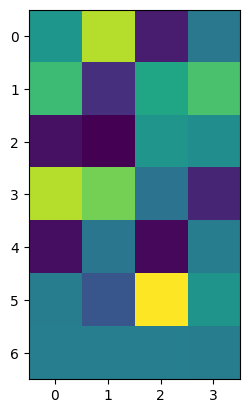

In [ ]:
lr = 0.05
n_step = 300
h0 = torch.zeros((1,n_hidd))
lossi = []
for j in range(n_step):
    hp = h0
    loss = 0
    for p in parameters:
        p.grad = None
        p.requires_grad = True
        ht, logits, probs = {}, {}, {}
    for i in range(len(Xtr)):
        ix = ctoi[Xtr[i]]
        iy = ctoi[Ytr[i]]
        #forward pass
        ht[i] = torch.tanh(Wxh[ix,:] + hp @ Whh + bh) 
        hp = ht[i]
        logits[i] = ht[i] @ Why + by
        probs[i] = torch.softmax(logits[i],dim=1)
        log_probs = probs[i].log()
        loss += -log_probs[i][0,iy]
    lossi.append(loss[i].item())
    h0 = hp.detach()
    #backward manually
    dWhh, dWxh, dWhy = torch.zeros_like(Whh), torch.zeros_like(Wxh), torch.zeros_like(Why)
    dby, dbh = torch.zeros_like(by), torch.zeros_like(bh)
    for i in range(len(Xtr)-1,-1,-1):
         dy = probs[i]
         dy[Ytr[i]] += -1
         dby += dy
         dWhy += ht[i].T @ dy
         
    loss.backward()
    for p in parameters:
            p.data += -lr * p.grad
    if j%25==0:
         print(f'prediction du modèle à {j} epoch: {predict('h',9)}')
import matplotlib.pyplot as plt
plt.imshow(torch.detach(Wxh).numpy())


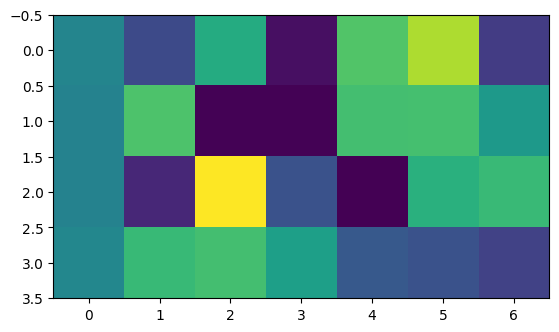

In [40]:
plt.imshow(torch.detach(Why).numpy())

In [41]:
with torch.no_grad():
    h = torch.zeros((1, n_hidd))

    result = 'h'
    for c in 'h':    
        ix = ctoi[c]
        h = torch.tanh(Wxh[ix, :] + h @ Whh + bh)
    po = torch.zeros((1,7))
    for _ in range(9):
        logits = h @ Why + by
        probs = torch.softmax(logits, dim=1)
        po = torch.cat((po,probs))
        ix = torch.multinomial(probs, 1).item()
        c = itoc[ix]
        result += c
        h = torch.tanh(Wxh[ix, :] + h @ Whh + bh)
    print(result)

helloworld


In [48]:
for i in range(3,0,-1):
    print(i)

3
2
1


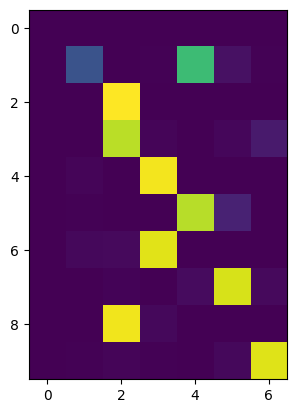

In [42]:
plt.imshow(torch.detach(po).numpy())

In [43]:
itoc

{0: 'h', 1: 'e', 2: 'l', 3: 'o', 4: 'w', 5: 'r', 6: 'd'}